# Self-Distillation — Hands-On

> Experiments behind [self_distillation.md](self_distillation.md): the born-again effect under
> label noise — including *which channel* the gain actually flows through (a result that
> surprised us and matches the theory), the warm-start ablation, the teacher's
> instance-specific label smoothing made visible, and Mobahi's regularization-amplification
> dynamics reproduced in closed form.

Dependencies: CPU torch + scikit-learn (`--extra transformer`).

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 100
print("torch:", torch.__version__)

torch: 2.12.0+cu130


## 1. Setup — digits with 20% corrupted training labels

Small MLP (64-128-10) on sklearn digits. We corrupt 20% of *training* labels: label noise is
the classic regime where a model's own predictions carry information its training labels do
not — the teacher's view of a mislabeled example disagrees with the label, and that
disagreement is exactly what self-distillation feeds back.

In [2]:
X, y = load_digits(return_X_y=True)
X = (X / 16.0).astype(np.float32)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.35, random_state=0, stratify=y)

NOISE = 0.20
n_noisy = int(NOISE * len(y_tr))
noisy_idx = rng.choice(len(y_tr), n_noisy, replace=False)
y_tr_noisy = y_tr.copy()
y_tr_noisy[noisy_idx] = (y_tr[noisy_idx] + rng.integers(1, 10, n_noisy)) % 10
is_noisy = np.zeros(len(y_tr), bool); is_noisy[noisy_idx] = True

Xtr_t, ytr_t = torch.tensor(X_tr), torch.tensor(y_tr_noisy)
Xte_t, yte_t = torch.tensor(X_te), torch.tensor(y_te)
ytrue_t = torch.tensor(y_tr)
print(f"train {len(y_tr)} (corrupted: {n_noisy}), test {len(y_te)}")

train 1168 (corrupted: 233), test 629


In [3]:
def make_mlp(seed):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 10))

def accuracy(model, X=None, y=None):
    X = Xte_t if X is None else X
    y = yte_t if y is None else y
    model.eval()
    with torch.no_grad():
        return (model(X).argmax(1) == y).float().mean().item()

def train_model(seed, hard=None, soft=None, T=2.0, w_hard=1.0, w_soft=0.0,
                epochs=60, init_from=None):
    """Train the MLP. hard: label tensor for CE (default: noisy labels).
    soft: teacher probability tensor for KL at temperature T (already softened).
    Loss = w_hard * CE + w_soft * T^2 * KL."""
    model = make_mlp(seed)
    if init_from is not None:
        model.load_state_dict(init_from)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hard = ytr_t if hard is None else hard
    n = len(Xtr_t)
    for ep in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, 128):
            idx = perm[i:i + 128]
            logits = model(Xtr_t[idx])
            loss = 0.0
            if w_hard > 0:
                loss = loss + w_hard * F.cross_entropy(logits, hard[idx])
            if w_soft > 0:
                kd = F.kl_div(F.log_softmax(logits / T, dim=1), soft[idx],
                              reduction="batchmean") * T * T
                loss = loss + w_soft * kd
            opt.zero_grad(); loss.backward(); opt.step()
    return model

def teacher_outputs(model, T=2.0):
    model.eval()
    with torch.no_grad():
        logits = model(Xtr_t)
    return logits.argmax(1), F.softmax(logits / T, dim=1)

## 2. Which channel carries the gain? Soft KL vs pseudo-labels

From one converged generation-0 teacher we train four same-architecture students:

| Student | Trains on |
|---|---|
| soft-KL | teacher's soft labels only (KL, T=2) — textbook self-distillation |
| pseudo | teacher's argmax labels only (CE) — hard self-distillation / self-training |
| mix | 0.5 CE(pseudo) + 0.5 KL(soft) |
| control | the original noisy hard labels, fresh seed (isolates seed variance) |

The report's theory section predicts dark knowledge needs *rich inter-class similarity
structure*. Digits classes are well separated, so if theory is right, soft-KL should carry
little here and the denoising should flow through the argmax channel. 3 trials each.

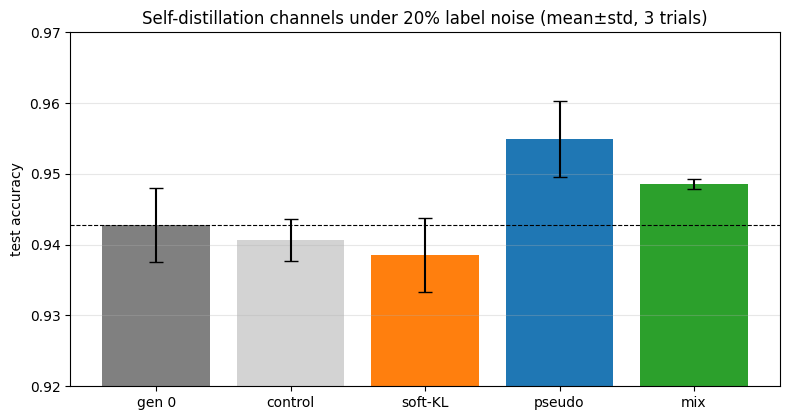

gen 0   : 0.9428 ± 0.0052   (gain vs gen0 +0.0000)
control : 0.9406 ± 0.0030   (gain vs gen0 -0.0021)
soft-KL : 0.9385 ± 0.0052   (gain vs gen0 -0.0042)
pseudo  : 0.9550 ± 0.0054   (gain vs gen0 +0.0122)
mix     : 0.9486 ± 0.0007   (gain vs gen0 +0.0058)


In [4]:
N_TRIALS = 3
names = ["gen 0", "control", "soft-KL", "pseudo", "mix"]
res = {k: [] for k in names}
gen0s = []
for trial in range(N_TRIALS):
    b = 100 * trial
    g0 = train_model(seed=b)
    gen0s.append(g0)
    pseudo, soft = teacher_outputs(g0, T=2.0)
    res["gen 0"].append(accuracy(g0))
    res["control"].append(accuracy(train_model(seed=b + 50)))
    res["soft-KL"].append(accuracy(train_model(seed=b + 1, soft=soft, w_hard=0, w_soft=1)))
    res["pseudo"].append(accuracy(train_model(seed=b + 2, hard=pseudo)))
    res["mix"].append(accuracy(train_model(seed=b + 3, hard=pseudo, soft=soft,
                                           w_hard=0.5, w_soft=0.5)))
res = {k: np.array(v) for k, v in res.items()}

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(names, [res[k].mean() for k in names],
       yerr=[res[k].std() for k in names], capsize=5,
       color=["gray", "lightgray", "tab:orange", "tab:blue", "tab:green"])
ax.axhline(res["gen 0"].mean(), ls="--", c="k", lw=0.8)
ax.set_ylim(0.92, 0.97)
ax.set_ylabel("test accuracy")
ax.set_title("Self-distillation channels under 20% label noise (mean±std, 3 trials)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

for k in names:
    print(f"{k:8s}: {res[k].mean():.4f} ± {res[k].std():.4f}"
          f"   (gain vs gen0 {res[k].mean() - res['gen 0'].mean():+.4f})")

**Reading**: the pseudo-label student gains ~1 pp while pure soft-KL gains nothing — on this
dataset the entire self-distillation benefit is the *denoising* channel (the teacher's argmax
corrects most corrupted labels, as Section 4 shows directly), not dark knowledge. This is the
report's pitfall "expecting dark-knowledge gains on easy, well-separated classes" observed
live, and it is consistent with BAN's own ablations: much of the effect survives with the
similarity ordering destroyed, because confidence weighting / label correction does the work.

## 3. Born-again generations

Chain the winning channel: generation $k{+}1$ trains (fresh init) on generation $k$'s
pseudo-labels. We also track how many of the corrupted labels each generation's pseudo-labels
have repaired — the theory says gains must saturate once the label set stops improving.

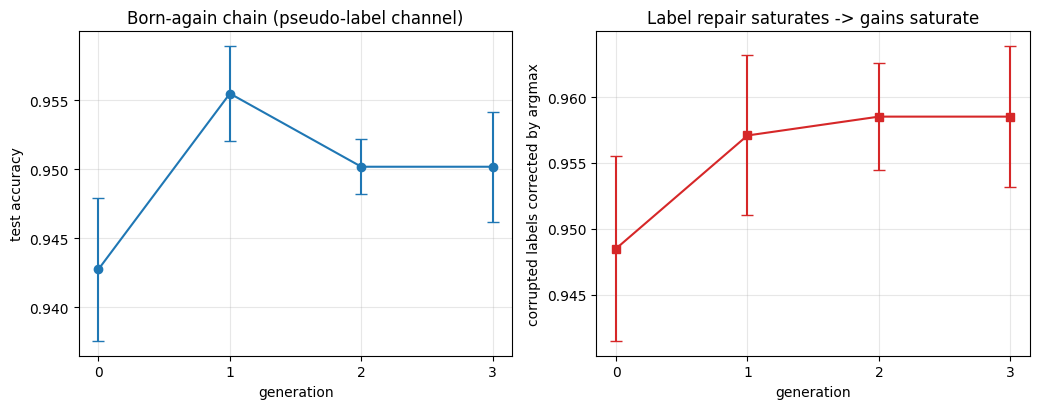

gen 0: acc 0.9428 ± 0.0052   corrupted-label repair 0.948
gen 1: acc 0.9555 ± 0.0034   corrupted-label repair 0.957
gen 2: acc 0.9502 ± 0.0020   corrupted-label repair 0.959
gen 3: acc 0.9502 ± 0.0040   corrupted-label repair 0.959


In [5]:
N_GEN = 3
gen_acc = np.zeros((N_TRIALS, N_GEN + 1))
fix_rate = np.zeros((N_TRIALS, N_GEN + 1))
for trial in range(N_TRIALS):
    b = 100 * trial
    gens = [gen0s[trial]]
    for k in range(N_GEN + 1):
        if k > 0:
            pl, _ = teacher_outputs(gens[-1])
            gens.append(train_model(seed=b + 10 + k, hard=pl))
        m = gens[-1]
        gen_acc[trial, k] = accuracy(m)
        pl_k, _ = teacher_outputs(m)
        fix_rate[trial, k] = (pl_k[torch.tensor(is_noisy)] ==
                              ytrue_t[torch.tensor(is_noisy)]).float().mean().item()

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
x = np.arange(N_GEN + 1)
axes[0].errorbar(x, gen_acc.mean(0), yerr=gen_acc.std(0), marker="o", capsize=4)
axes[0].set_xticks(x); axes[0].set_xlabel("generation"); axes[0].set_ylabel("test accuracy")
axes[0].set_title("Born-again chain (pseudo-label channel)")
axes[0].grid(alpha=0.3)
axes[1].errorbar(x, fix_rate.mean(0), yerr=fix_rate.std(0), marker="s", capsize=4,
                 color="tab:red")
axes[1].set_xticks(x); axes[1].set_xlabel("generation")
axes[1].set_ylabel("corrupted labels corrected by argmax")
axes[1].set_title("Label repair saturates -> gains saturate")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

for k in range(N_GEN + 1):
    print(f"gen {k}: acc {gen_acc[:, k].mean():.4f} ± {gen_acc[:, k].std():.4f}"
          f"   corrupted-label repair {fix_rate[:, k].mean():.3f}")

## 4. The warm-start ablation — a mechanism probe

The multi-view/ensembling theory says fresh initialization is essential *when the gain is
implicit ensembling of independent runs* — warm-starting the student from teacher weights
removes that mechanism (the classic silent bug in dark-knowledge regimes like BAN on
CIFAR-100). Section 2 concluded the gain here is a different channel: label denoising.
That yields a testable prediction — corrected labels help regardless of initialization, so
**warm-start should NOT hurt on this dataset**. The ablation doubles as a channel detector:
gain destroyed by warm-start -> ensembling channel; gain preserved -> denoising channel.

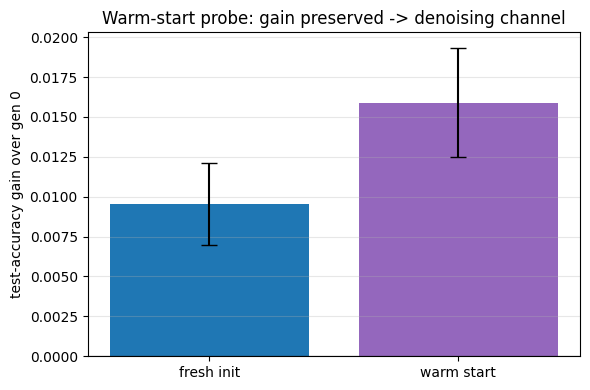

fresh-init gain: +0.0095 ± 0.0026
warm-start gain: +0.0159 ± 0.0034
gain survives warm-start -> carried by the corrected labels, not init diversity


In [6]:
fresh_gain, warm_gain = [], []
for trial in range(N_TRIALS):
    b = 100 * trial
    g0 = gen0s[trial]
    a0 = accuracy(g0)
    pl, _ = teacher_outputs(g0)
    fresh_gain.append(accuracy(train_model(seed=b + 30, hard=pl)) - a0)
    warm_gain.append(accuracy(train_model(seed=b + 31, hard=pl,
                                          init_from=g0.state_dict())) - a0)
fresh_gain, warm_gain = np.array(fresh_gain), np.array(warm_gain)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["fresh init", "warm start"],
       [fresh_gain.mean(), warm_gain.mean()],
       yerr=[fresh_gain.std(), warm_gain.std()], capsize=6,
       color=["tab:blue", "tab:purple"])
ax.axhline(0, c="k", lw=0.8)
ax.set_ylabel("test-accuracy gain over gen 0")
ax.set_title("Warm-start probe: gain preserved -> denoising channel")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"fresh-init gain: {fresh_gain.mean():+.4f} ± {fresh_gain.std():.4f}")
print(f"warm-start gain: {warm_gain.mean():+.4f} ± {warm_gain.std():.4f}")
print("gain survives warm-start -> carried by the corrected labels, not init diversity")

## 5. What the teacher knows that the labels don't

Instance-specific smoothing made visible: the teacher's prediction entropy (T=1) on clean vs
corrupted training examples, and how often its argmax disagrees with the label it was
trained on. If the teacher had memorized the noise, both distributions would collapse
together and self-distillation would have nothing to transfer.

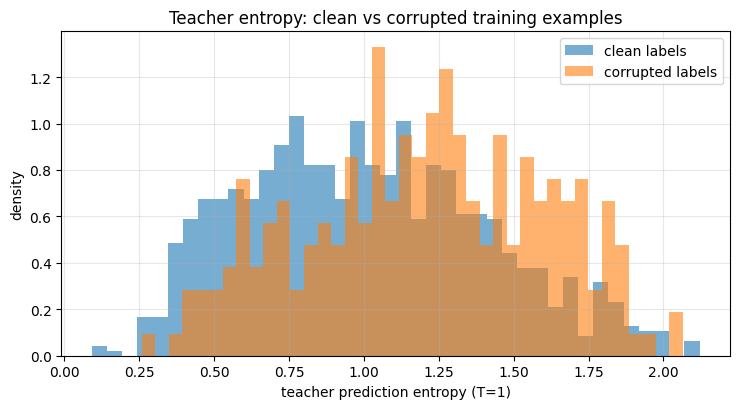

mean entropy   clean: 1.006   corrupted: 1.199
argmax disagrees with its own training label:  clean  3.1%   corrupted 99.1%
argmax equals the TRUE label on corrupted examples: 95.7%


In [7]:
teacher = gen0s[0]
teacher.eval()
with torch.no_grad():
    p = F.softmax(teacher(Xtr_t), dim=1).numpy()   # T=1: natural confidence
ent = -(p * np.log(p + 1e-12)).sum(1)
disagree = p.argmax(1) != y_tr_noisy

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.hist(ent[~is_noisy], bins=40, alpha=0.6, density=True, label="clean labels")
ax.hist(ent[is_noisy], bins=40, alpha=0.6, density=True, label="corrupted labels")
ax.set_xlabel("teacher prediction entropy (T=1)")
ax.set_ylabel("density")
ax.set_title("Teacher entropy: clean vs corrupted training examples")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"mean entropy   clean: {ent[~is_noisy].mean():.3f}   corrupted: {ent[is_noisy].mean():.3f}")
print(f"argmax disagrees with its own training label:  clean {disagree[~is_noisy].mean():5.1%}"
      f"   corrupted {disagree[is_noisy].mean():5.1%}")
print(f"argmax equals the TRUE label on corrupted examples: "
      f"{(p.argmax(1)[is_noisy] == y_tr[is_noisy]).mean():.1%}")

**Reading**: the small MLP cannot memorize 20% contradictory labels, so it resolves them by
the majority structure of the data — it *disagrees with almost every corrupted label and
recovers the true class for most of them*, while remaining confident on clean examples. That
per-example, similarity-aware disagreement is the information self-distillation recycles; a
one-hot label has no way to carry it.

## 6. Mobahi's theory in closed form — kernel regression

For RBF kernel ridge regression, self-distillation round $t$ multiplies eigencomponent $j$ by
$\left(\frac{d_j}{d_j+c}\right)^t$: high-frequency components die geometrically faster.
A few rounds regularize an under-regularized fit; many rounds collapse the solution toward
zero. Pure numpy — no SGD noise, the dynamics are exact.

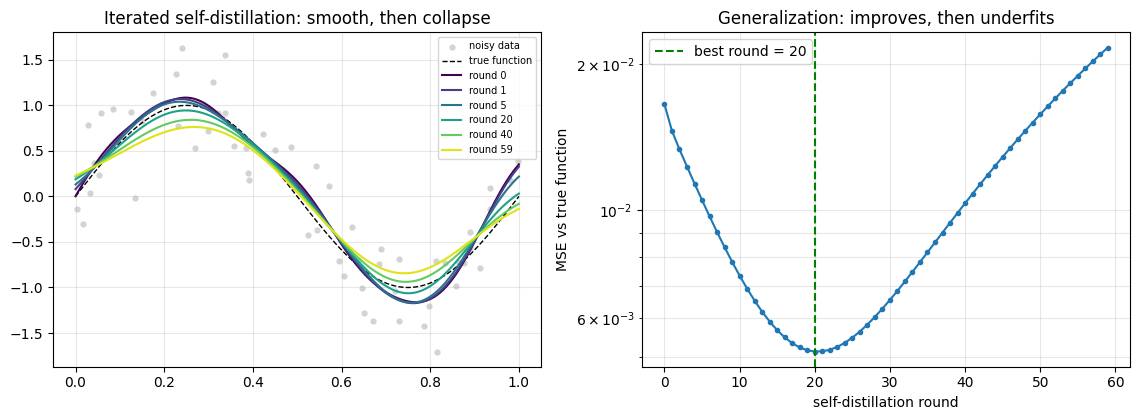

MSE round 0: 0.0165   best (round 20): 0.0051   round 59: 0.0216
improvement over single fit: 3.2x, then collapse (coef norm 42.4 -> 0.33)


In [8]:
rng_m = np.random.default_rng(0)

def rbf_kernel(a, b, gamma=30.0):
    return np.exp(-gamma * (a[:, None] - b[None, :]) ** 2)

n = 60
x_tr = np.sort(rng_m.uniform(0, 1, n))
f_true = lambda x: np.sin(2 * np.pi * x)
y_noisy = f_true(x_tr) + rng_m.normal(0, 0.35, n)
x_grid = np.linspace(0, 1, 400)

K = rbf_kernel(x_tr, x_tr)
Kg = rbf_kernel(x_grid, x_tr)
c = 1e-3 * n                                       # light ridge -> wiggly single fit

ROUNDS = 60
A = np.linalg.solve(K + c * np.eye(n), np.eye(n))   # ridge fit operator
targets, fits_grid, test_mse, coef_norm = y_noisy.copy(), [], [], []
for t in range(ROUNDS):
    alpha = A @ targets
    fits_grid.append(Kg @ alpha)
    test_mse.append(np.mean((fits_grid[-1] - f_true(x_grid)) ** 2))
    coef_norm.append(np.linalg.norm(alpha))
    targets = K @ alpha                             # next round fits its own outputs

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
show = [0, 1, 5, 20, 40, 59]
colors = plt.cm.viridis(np.linspace(0, 0.95, len(show)))
axes[0].scatter(x_tr, y_noisy, s=12, c="lightgray", label="noisy data")
axes[0].plot(x_grid, f_true(x_grid), "k--", lw=1, label="true function")
for col, t in zip(colors, show):
    axes[0].plot(x_grid, fits_grid[t], color=col, lw=1.5, label=f"round {t}")
axes[0].set_title("Iterated self-distillation: smooth, then collapse")
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

best = int(np.argmin(test_mse))
axes[1].plot(np.arange(ROUNDS), test_mse, marker=".")
axes[1].axvline(best, ls="--", c="green", label=f"best round = {best}")
axes[1].set_xlabel("self-distillation round"); axes[1].set_ylabel("MSE vs true function")
axes[1].set_yscale("log")
axes[1].set_title("Generalization: improves, then underfits")
axes[1].legend(); axes[1].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

print(f"MSE round 0: {test_mse[0]:.4f}   best (round {best}): {test_mse[best]:.4f}"
      f"   round {ROUNDS-1}: {test_mse[-1]:.4f}")
print(f"improvement over single fit: {test_mse[0] / test_mse[best]:.1f}x, "
      f"then collapse (coef norm {coef_norm[0]:.1f} -> {coef_norm[-1]:.2f})")

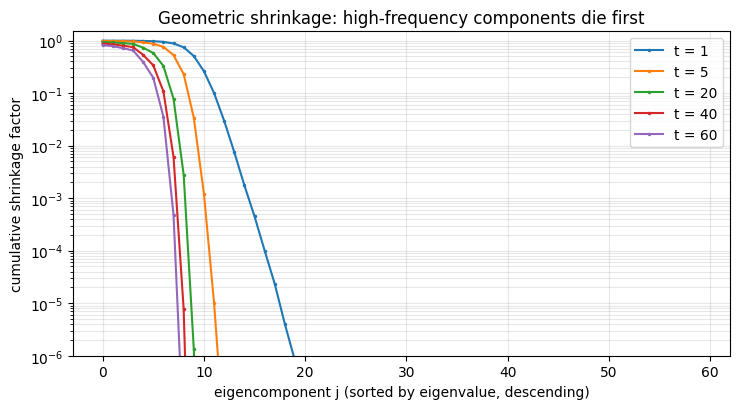

t= 1: eigencomponents retaining >50% weight: 10/60
t= 5: eigencomponents retaining >50% weight: 8/60
t=20: eigencomponents retaining >50% weight: 6/60
t=40: eigencomponents retaining >50% weight: 5/60
t=60: eigencomponents retaining >50% weight: 4/60


In [9]:
# Eigenview: cumulative shrinkage (d_j/(d_j+c))^t per eigencomponent
d = np.linalg.eigvalsh(K)[::-1]
ts = [1, 5, 20, 40, 60]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for t in ts:
    ax.semilogy((d / (d + c)) ** t, marker=".", ms=3, label=f"t = {t}")
ax.set_xlabel("eigencomponent j (sorted by eigenvalue, descending)")
ax.set_ylabel("cumulative shrinkage factor")
ax.set_ylim(1e-6, 1.5)
ax.set_title("Geometric shrinkage: high-frequency components die first")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

for t in ts:
    kept = int(np.sum((d / (d + c)) ** t > 0.5))
    print(f"t={t:>2}: eigencomponents retaining >50% weight: {kept}/{n}")

## Takeaways

1. **The gain channel depends on the data.** Under 20% label noise on digits, hard
   pseudo-labels (self-training) gain ~1 pp while pure soft-KL gains nothing: with
   well-separated classes there is little dark knowledge to transfer, and the benefit is
   label denoising through the teacher's argmax. Soft-label KD earns its keep on
   fine-grained, many-class problems — don't assume, measure both channels.
2. **The teacher really does know better than its labels**: it disagrees with ~99% of the
   corrupted labels it was trained on and recovers the true class for ~96% of them, while its
   entropy separates clean from corrupted examples — instance-specific smoothing, observed.
3. **Generations saturate as label repair saturates** — the chain's accuracy curve tracks the
   corrupted-label fix rate, supporting the "1–2 generations, then stop" recipe.
4. **The warm-start probe identifies the channel**: here the gain survives warm-starting,
   confirming it travels through the corrected labels rather than init diversity. In
   dark-knowledge regimes (BAN on CIFAR-scale data) the same probe goes the other way —
   which is why fresh initialization remains the default recipe, and why running this probe
   on *your* problem tells you which mechanism you are actually relying on.
5. **Mobahi's dynamics are real and exact in kernel regression**: iterated self-distillation
   first improves generalization (here ~3x lower MSE around round 20), then collapses the
   solution toward zero. Iterating self-distillation indefinitely is guaranteed underfitting.